# EXP_11: Passage-Level SHAP Explainability

Measures the **Shapley-value contribution** of each retrieved passage to the final answer
using KernelSHAP.

**Method:** Each passage is a binary feature. A prediction function takes a binary mask,
constructs the context from active passages, calls Groq LLaMA 3.3 70B to regenerate the
answer, and returns a ROUGE-L score against the golden answer. KernelSHAP estimates the
marginal contribution of each passage by evaluating passage subsets.

**Key difference from LIME (EXP_10):** SHAP accounts for feature interactions via
Shapley axioms (efficiency, symmetry, null player). LIME fits a local linear model that
may miss interaction effects.

**Target architectures:**
- Evidence-Graded RAG (5 graded passages per question — the top-5 actually fed to the generator)
- Query Decomposition RAG (5 passages per question)

**Important:** For Evidence-Graded RAG, we use `graded_contexts` (the 5 passages the generator
actually saw), not `retrieved_contexts` (the 8-passage candidate pool). Attributing influence
to passages the LLM never received would be methodologically invalid.

In [5]:
import sys
sys.path.append("..")

import os
import time
import json
import numpy as np
import pandas as pd
from ast import literal_eval
from datetime import datetime
from concurrent.futures import ThreadPoolExecutor, as_completed

import shap
import matplotlib.pyplot as plt
import seaborn as sns
from rouge_score import rouge_scorer
from langchain_groq import ChatGroq
from langchain_core.prompts import PromptTemplate

import config

pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid", font_scale=1.1)

RESULTS_DIR = config.RESULTS_EVALSETS_DIR
DEEPEVAL_DIR = config.RESULTS_DEEPEVAL_DIR
FIGURES_DIR = config.RESULTS_FIGURES_DIR

## Configuration

In [6]:
ARCHITECTURES = {
    "Evidence-Graded RAG": {
        "eval_file": "evidence_graded_rag_minilm_chroma_20260516_164252.csv",
        "faithfulness_file": "evidence_graded_rag_minilm_faithfulness_20260516_164252.csv",
        "correctness_file": "evidence_graded_rag_minilm_answer_correctness_20260516_164252.csv",
    },
    "Query Decomposition RAG": {
        "eval_file": "decomposition_rag_minilm_k_5_20260518_181816.csv",
        "faithfulness_file": "decomposition_rag_minilm_faithfulness_20260518_181816.csv",
        "correctness_file": "decomposition_rag_minilm_answer_correctness_20260518_181816.csv",
    },
}

SEVERITY_FILE = "golden_dataset_with_severity.csv"

# XAI workloads send ~968 tokens per call (weighted avg across coalition sizes).
# At 4s delay that's ~14,520 TPM per key, exceeding Groq's 12K TPM limit.
# 10s delay → ~5,808 avg TPM, ~8,880 peak TPM — safely under 12K.
XAI_GROQ_DELAY = 10
ROWS_PER_KEY = config.PARALLEL_BUCKET_SIZE

# KernelSHAP samples — with 5 passages (features), the exact Shapley computation
# requires only 2^5 = 32 subsets. This covers the full coalition space with no
# sampling approximation, giving exact SHAP values.
SHAP_NSAMPLES = 32

# Stratified sample: 30 questions sampled by medical severity tier
# (10 from each of Low / Medium / High). Severity is a domain-native
# 3-bucket categorisation of clinical importance. It produces balanced
# strata (22 Low / 122 Medium / 56 High in the dataset) and ensures XAI
# analysis covers questions across all clinical importance levels.
# Faithfulness was rejected as a stratification variable because 87–94%
# of questions score exactly 1.0, collapsing tertile/quartile splits
# into a single group.
XAI_SAMPLE_SIZE = 30

# Shared cache for raw (mask → ROUGE-L score) pairs.
# Both LIME and SHAP evaluate the same 2^5 coalitions; saving the raw
# scores lets whichever notebook runs second skip all LLM calls.
XAI_SCORES_CACHE_DIR = RESULTS_DIR / "xai_scores_cache"
XAI_SCORES_CACHE_DIR.mkdir(parents=True, exist_ok=True)

EVIDENCE_GRADED_PROMPT = """You are a biomedical research assistant. Use the following research contexts to answer the question.

Context:
{context}

Question: {question}

Instructions:
- Synthesize an answer from the provided context using evidence-based reasoning.
- Draw logical inferences and conclusions from the evidence when a direct statement is not available.
- Cite specific findings, statistics, or conclusions from the context to support your answer.
- Do NOT refuse to answer or state that the context is insufficient. Use whatever relevant evidence is available.

Answer:"""

DECOMPOSITION_PROMPT = """Use the following research contexts to answer the question.

Context:
{context}

Question: {question}

Answer based only on the provided context. Be precise and evidence-based.

Answer:"""

PROMPTS = {
    "Evidence-Graded RAG": EVIDENCE_GRADED_PROMPT,
    "Query Decomposition RAG": DECOMPOSITION_PROMPT,
}

## Groq Client, Scoring & Parallel Infrastructure

In [7]:
class GroqKeyRotator:
    """Cycles through config.GROQ_API_KEYS, rebuilding the LLM client on each rotation."""

    def __init__(self, model=None):
        if not config.GROQ_API_KEYS:
            raise ValueError("config.GROQ_API_KEYS is empty — set GROQ_API_KEY or GROQ_API_KEYS in .env")
        self.api_keys = config.GROQ_API_KEYS
        self.model = model or config.LLM_MODEL
        self.current_idx = 0
        print(f"Initialized GroqKeyRotator with {len(self.api_keys)} API key(s)")

    def get_llm(self):
        return ChatGroq(
            model=self.model,
            api_key=self.api_keys[self.current_idx],
            temperature=0,
            max_tokens=900,
        )

    def rotate(self):
        self.current_idx = (self.current_idx + 1) % len(self.api_keys)


def is_rate_limit_error(e):
    """Check if an exception is a rate limit error."""
    msg = str(e).lower()
    return any(kw in msg for kw in [
        "rate_limit", "rate limit", "429", "too many requests",
        "tokens per", "token limit", "exceeded",
    ])


rouge = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)


def score_answer(generated: str, golden: str) -> float:
    return rouge.score(golden, generated)["rougeL"].fmeasure


def generate_answer(question: str, passages: list[str], prompt_template: str, api_key: str, model: str) -> str:
    """Call Groq to generate an answer from the given passages using a specific API key."""
    context = "\n\n---\n\n".join(passages) if passages else "No context available."
    prompt = PromptTemplate(
        template=prompt_template, input_variables=["context", "question"]
    )
    llm = ChatGroq(model=model, api_key=api_key, temperature=0, max_tokens=900)
    chain = prompt | llm
    result = chain.invoke({"context": context, "question": question})
    return result.content


key_rotator = GroqKeyRotator()

Initialized GroqKeyRotator with 16 API key(s)


## Load Eval Datasets

### IF Lime Run before and already stored the passages

In [8]:
datasets = {}
for arch_name in ARCHITECTURES:
    df = pd.read_csv(RESULTS_DIR / f"{arch_name.lower().replace(' ', '_')}_for_xai.csv")
    df["passages_for_xai"] = df["passages_for_xai"].apply(literal_eval)
    datasets[arch_name] = df

### IF Lime not run before then create new passage dfs

In [ ]:
severity_df = pd.read_csv(config.DATA_PROCESSED_DIR / SEVERITY_FILE)[["question_idx", "severity_tier"]]

datasets = {}
for arch_name, files in ARCHITECTURES.items():
    df = pd.read_csv(RESULTS_DIR / files["eval_file"])

    if "graded_contexts" in df.columns:
        df["graded_contexts"] = df["graded_contexts"].apply(literal_eval)
        df["passages_for_xai"] = df["graded_contexts"]
    else:
        df["retrieved_contexts"] = df["retrieved_contexts"].apply(literal_eval)
        df["passages_for_xai"] = df["retrieved_contexts"]

    df["num_passages"] = df["passages_for_xai"].apply(len)

    faith_df = pd.read_csv(DEEPEVAL_DIR / files["faithfulness_file"])
    faith_col = [c for c in faith_df.columns if "faithfulness" in c.lower() or "Faithfulness" in c]
    if faith_col:
        if "question_idx" in faith_df.columns:
            df = df.merge(faith_df[["question_idx", faith_col[0]]], on="question_idx", how="left")
        else:
            df["faithfulness"] = faith_df[faith_col[0]].values[:len(df)]

    corr_df = pd.read_csv(DEEPEVAL_DIR / files["correctness_file"])
    corr_col = [c for c in corr_df.columns if "correctness" in c.lower() or "Correctness" in c]
    if corr_col:
        if "question_idx" in corr_df.columns:
            df = df.merge(corr_df[["question_idx", corr_col[0]]], on="question_idx", how="left", suffixes=("", "_corr"))
        else:
            df["answer_correctness"] = corr_df[corr_col[0]].values[:len(df)]

    # Join severity tiers
    df = df.merge(severity_df, on="question_idx", how="left")

    # Stratified sample: 10 questions from each severity tier (Low / Medium / High)
    if XAI_SAMPLE_SIZE < len(df) and "severity_tier" in df.columns:
        per_tier = XAI_SAMPLE_SIZE // 3
        sampled = df.groupby("severity_tier", group_keys=False).apply(
            lambda g: g.sample(n=min(len(g), per_tier), random_state=42)
        ).head(XAI_SAMPLE_SIZE)
        df = sampled.reset_index(drop=True)
        print(f"  Stratified sample by severity: {len(df)} questions")
        print(f"    {df['severity_tier'].value_counts().to_dict()}")
    elif XAI_SAMPLE_SIZE < len(df):
        df = df.sample(n=XAI_SAMPLE_SIZE, random_state=42).reset_index(drop=True)
        print(f"  Random sample: {len(df)} questions")

    datasets[arch_name] = df
    ctx_source = "graded_contexts" if "graded_contexts" in df.columns else "retrieved_contexts"
    print(f"{arch_name}: {len(df)} questions, {df['num_passages'].iloc[0]} passages each (from {ctx_source})")

## KernelSHAP Prediction Function

SHAP's KernelExplainer needs a function `f(X)` where X is an (n_samples, n_features)
binary matrix. Each row is a mask; we generate answers for each mask and return ROUGE-L scores.

We cache results to avoid redundant LLM calls for the same mask within a question.

In [11]:
def make_predict_fn(question: str, passages: list[str], golden_answer: str,
                    prompt_template: str, api_key: str, model: str,
                    cache_file=None):
    """Create a prediction function for a single question (closure over passages and API key).

    If cache_file exists, pre-loads cached (mask → score) pairs to skip LLM calls.
    Returns (predict_fn, save_cache_fn).
    """
    cache = {}
    if cache_file and cache_file.exists():
        with open(cache_file) as f:
            raw = json.load(f)
        cache = {tuple(map(int, k.split(","))): v for k, v in raw.items()}

    def predict(X: np.ndarray) -> np.ndarray:
        scores = []
        for mask in X:
            key = tuple(mask.astype(int))
            if key in cache:
                scores.append(cache[key])
                continue
            active = [p for p, m in zip(passages, mask) if m == 1]
            answer = generate_answer(question, active, prompt_template, api_key, model)
            s = score_answer(answer, golden_answer)
            cache[key] = s
            scores.append(s)
            time.sleep(XAI_GROQ_DELAY)
        return np.array(scores)

    def save_cache():
        if cache_file:
            cache_file.parent.mkdir(parents=True, exist_ok=True)
            serializable = {",".join(map(str, k)): v for k, v in cache.items()}
            with open(cache_file, "w") as f:
                json.dump(serializable, f, indent=2)

    return predict, save_cache

## Parallel SHAP Execution Engine

Each API key processes a contiguous slice of questions in its own thread.
Within each thread, questions are processed sequentially. KernelSHAP evaluates
32 coalitions per question (exact Shapley values for 5 passages).

The `resume_shap_from_csv` function identifies failed questions and reruns only those.

In [12]:
def _run_shap_slice(slice_df, api_key, model, prompt_template, delay, key_idx, done_indices, cache_dir=None):
    """Process a contiguous slice of questions using KernelSHAP with a dedicated API key."""
    results = []
    n_passages = slice_df["num_passages"].iloc[0]
    background = np.zeros((1, n_passages))

    for row_idx, (_, row) in enumerate(slice_df.iterrows()):
        q_idx = row["question_idx"]
        if q_idx in done_indices:
            continue

        question = row["question"]
        passages = row["passages_for_xai"]
        golden_answer = row["golden_answer"]

        cache_file = cache_dir / f"q{q_idx}.json" if cache_dir else None
        cache_hit = cache_file and cache_file.exists()
        label = "cached" if cache_hit else "LLM"
        print(f"  [Key {key_idx}] Q{q_idx} ({label}): {question[:70]}...")
        try:
            predict_fn, save_cache = make_predict_fn(
                question, passages, golden_answer, prompt_template, api_key, model,
                cache_file=cache_file,
            )
            explainer = shap.KernelExplainer(predict_fn, background)
            test_instance = np.ones((1, n_passages))
            shap_values = explainer.shap_values(test_instance, nsamples=SHAP_NSAMPLES, silent=True)

            save_cache()

            sv = shap_values[0] if isinstance(shap_values, list) else shap_values.flatten()

            record = {
                "question_idx": q_idx,
                "question": question,
                "num_passages": n_passages,
                "base_value": float(explainer.expected_value) if np.isscalar(explainer.expected_value) else float(explainer.expected_value[0]),
            }
            for p_idx, val in enumerate(sv):
                record[f"passage_{p_idx}_shap"] = float(val)

            ranking = np.argsort(np.abs(sv))[::-1]
            record["passage_ranking"] = json.dumps(ranking.tolist())
            record["top1_passage_idx"] = int(ranking[0])
            record["top3_passage_indices"] = json.dumps(ranking[:3].tolist())

            results.append(record)

        except Exception as e:
            print(f"  [Key {key_idx}] ERROR on Q{q_idx}: {e}")
            if is_rate_limit_error(e):
                time.sleep(delay * 3)
            continue

    completed = len(results)
    print(f"[Key {key_idx}] Done — {completed}/{len(slice_df)} questions processed")
    return results


def run_shap_parallel(df, key_rotator, prompt_template, output_file,
                      rows_per_key=None, delay=None, cache_dir=None):
    """Run KernelSHAP across all questions using parallel API keys.

    Distributes questions across available API keys via ThreadPoolExecutor.
    Automatically resumes from checkpoint if output_file already exists.
    """
    rows_per_key = rows_per_key or ROWS_PER_KEY
    delay = delay or XAI_GROQ_DELAY
    api_keys = key_rotator.api_keys

    # Resume from checkpoint if exists
    if output_file.exists():
        existing = pd.read_csv(output_file)
        done_indices = set(existing["question_idx"].values)
        print(f"Resuming from checkpoint: {len(done_indices)} questions already done")
    else:
        existing = pd.DataFrame()
        done_indices = set()

    # Filter to only unfinished questions
    remaining_df = df[~df["question_idx"].isin(done_indices)].copy().reset_index(drop=True)
    if remaining_df.empty:
        print("All questions already completed.")
        return existing

    total_capacity = len(api_keys) * rows_per_key
    if len(remaining_df) > total_capacity:
        print(f"Warning: {len(remaining_df)} rows exceed capacity ({total_capacity}). Truncating.")
        remaining_df = remaining_df.iloc[:total_capacity]

    # Create contiguous slices, one per API key
    slices = []
    for i, key in enumerate(api_keys):
        start = i * rows_per_key
        if start >= len(remaining_df):
            break
        slices.append((key, i, remaining_df.iloc[start: start + rows_per_key]))

    print(f"\n{len(remaining_df)} questions split across {len(slices)} key(s) ({rows_per_key} questions/key max):")
    for key, i, s in slices:
        print(f"  Key {i}: {len(s)} questions")

    ordered_results = [None] * len(slices)
    with ThreadPoolExecutor(max_workers=len(slices)) as executor:
        future_to_idx = {
            executor.submit(
                _run_shap_slice,
                s, key, key_rotator.model, prompt_template, delay, i, done_indices, cache_dir,
            ): idx
            for idx, (key, i, s) in enumerate(slices)
        }
        for future in as_completed(future_to_idx):
            idx = future_to_idx[future]
            try:
                ordered_results[idx] = future.result()
            except Exception as e:
                print(f"[Key {idx}] Thread failed: {e}")
                ordered_results[idx] = []

    # Merge all new results with existing
    all_new_results = []
    for key_results in ordered_results:
        if key_results:
            all_new_results.extend(key_results)

    if all_new_results:
        new_df = pd.DataFrame(all_new_results)
        if not existing.empty:
            final_df = pd.concat([existing, new_df], ignore_index=True)
        else:
            final_df = new_df
    else:
        final_df = existing

    final_df = final_df.sort_values("question_idx").reset_index(drop=True)
    final_df.to_csv(output_file, index=False)
    completed = len(final_df)
    total = len(df)
    print(f"\nCompleted {completed}/{total} questions total")
    print(f"Saved to {output_file}")
    return final_df


def resume_shap_from_csv(df, output_file, key_rotator, prompt_template,
                         rows_per_key=None, delay=None, cache_dir=None):
    """Resume an interrupted SHAP run by reprocessing only missing questions."""
    if not output_file.exists():
        print("No existing results found. Running full SHAP computation.")
        return run_shap_parallel(df, key_rotator, prompt_template, output_file,
                                rows_per_key=rows_per_key, delay=delay, cache_dir=cache_dir)

    existing = pd.read_csv(output_file)
    completed_indices = set(existing["question_idx"].values)
    missing_df = df[~df["question_idx"].isin(completed_indices)]

    if missing_df.empty:
        print("All questions already completed.")
        return existing

    print(f"Need to recompute {len(missing_df)} questions.")
    return run_shap_parallel(df, key_rotator, prompt_template, output_file,
                            rows_per_key=rows_per_key, delay=delay, cache_dir=cache_dir)

## Run SHAP: Evidence-Graded RAG
Processes a stratified sample of 30 questions for Evidence-Graded RAG. Questions are distributed across
API keys and processed in parallel. Each question requires 32 LLM calls (exact coalitions).

Run `resume_shap_from_csv` in the next cell to retry any questions that failed
due to rate limits or transient errors.

In [16]:
arch_name = "Evidence-Graded RAG"
arch_slug = arch_name.lower().replace(" ", "_")
output_file = RESULTS_DIR / f"shap_passage_scores_{arch_slug}.csv"
cache_dir = XAI_SCORES_CACHE_DIR / arch_slug

shap_eg_df = run_shap_parallel(
    datasets[arch_name], key_rotator, PROMPTS[arch_name], output_file,
    rows_per_key=1, cache_dir=cache_dir,
)
print(f"\n{arch_name}: {len(shap_eg_df)} questions completed")


16 questions split across 16 key(s) (1 questions/key max):
  Key 0: 1 questions
  Key 1: 1 questions
  Key 2: 1 questions
  Key 3: 1 questions
  Key 4: 1 questions
  Key 5: 1 questions
  Key 6: 1 questions
  Key 7: 1 questions
  Key 8: 1 questions
  Key 9: 1 questions
  Key 10: 1 questions
  Key 11: 1 questions
  Key 12: 1 questions
  Key 13: 1 questions
  Key 14: 1 questions
  Key 15: 1 questions
  [Key 0] Q9 (LLM): Pancreas retransplantation:  a second chance for diabetic patients?...
  [Key 1] Q31 (LLM): Does early migraine treatment shorten time to headache peak and reduce...
  [Key 2] Q141 (LLM): Does limb-salvage surgery offer patients better quality of life and fu...
  [Key 3] Q58 (LLM): Metered-dose inhalers. Do health care providers know what to teach?...
  [Key 4] Q74 (LLM): Does a family meetings intervention prevent depression and anxiety in ...
  [Key 5] Q183 (LLM): Do preoperative statin therapy and laparoscopic surgery reduce the ris...
  [Key 6] Q149 (LLM): Combining p

In [13]:
# Resume Evidence-Graded RAG — rerun only failed/missing questions
arch_name = "Evidence-Graded RAG"
arch_slug = arch_name.lower().replace(" ", "_")
output_file = RESULTS_DIR / f"shap_passage_scores_{arch_slug}.csv"
cache_dir = XAI_SCORES_CACHE_DIR / arch_slug

shap_eg_df = resume_shap_from_csv(
    datasets[arch_name], output_file, key_rotator, PROMPTS[arch_name],
    rows_per_key=1, delay=XAI_GROQ_DELAY, cache_dir=cache_dir)

Need to recompute 14 questions.
Resuming from checkpoint: 16 questions already done

14 questions split across 14 key(s) (1 questions/key max):
  Key 0: 1 questions
  Key 1: 1 questions
  Key 2: 1 questions
  Key 3: 1 questions
  Key 4: 1 questions
  Key 5: 1 questions
  Key 6: 1 questions
  Key 7: 1 questions
  Key 8: 1 questions
  Key 9: 1 questions
  Key 10: 1 questions
  Key 11: 1 questions
  Key 12: 1 questions
  Key 13: 1 questions
  [Key 0] Q174 (LLM): How do demographic factors such as ethnicity, cultural background, age...
  [Key 2] Q19 (LLM): Is endometrial polyp formation associated with increased expression of...
  [Key 1] Q73 (LLM): Canada's Compassionate Care Benefit: is it an adequate public health r...
  [Key 3] Q21 (LLM): Are performance measurement systems useful?...
  [Key 4] Q27 (LLM): Is robotically assisted laparoscopic radical prostatectomy less invasi...
  [Key 5] Q80 (LLM): Does quantitative left ventricular regional wall motion change after f...
  [Key 6] Q82 

## Run SHAP: Query Decomposition RAG
Processes a stratified sample of 30 questions for Query Decomposition RAG with the same parallel
infrastructure. Run the resume cell below to retry any failed questions.

In [15]:
arch_name = "Query Decomposition RAG"
arch_slug = arch_name.lower().replace(" ", "_")
output_file = RESULTS_DIR / f"shap_passage_scores_{arch_slug}.csv"
cache_dir = XAI_SCORES_CACHE_DIR / arch_slug

shap_qd_df = run_shap_parallel(
    datasets[arch_name], key_rotator, PROMPTS[arch_name], output_file,
    rows_per_key=1, cache_dir=cache_dir,
)
print(f"\n{arch_name}: {len(shap_qd_df)} questions completed")


16 questions split across 16 key(s) (1 questions/key max):
  Key 0: 1 questions
  Key 1: 1 questions
  Key 2: 1 questions
  Key 3: 1 questions
  Key 4: 1 questions
  Key 5: 1 questions
  Key 6: 1 questions
  Key 7: 1 questions
  Key 8: 1 questions
  Key 9: 1 questions
  Key 10: 1 questions
  Key 11: 1 questions
  Key 12: 1 questions
  Key 13: 1 questions
  Key 14: 1 questions
  Key 15: 1 questions
  [Key 0] Q9 (LLM): Pancreas retransplantation:  a second chance for diabetic patients?...
  [Key 1] Q31 (LLM): Does early migraine treatment shorten time to headache peak and reduce...
  [Key 2] Q141 (LLM): Does limb-salvage surgery offer patients better quality of life and fu...
  [Key 4] Q74 (LLM): Does a family meetings intervention prevent depression and anxiety in ...
  [Key 3] Q58 (LLM): Metered-dose inhalers. Do health care providers know what to teach?...
  [Key 5] Q183 (LLM): Do preoperative statin therapy and laparoscopic surgery reduce the ris...
  [Key 6] Q149 (LLM): Combining p

In [16]:
# Resume Query Decomposition RAG — rerun only failed/missing questions
arch_name = "Query Decomposition RAG"
arch_slug = arch_name.lower().replace(" ", "_")
output_file = RESULTS_DIR / f"shap_passage_scores_{arch_slug}.csv"
cache_dir = XAI_SCORES_CACHE_DIR / arch_slug

shap_qd_df = resume_shap_from_csv(
    datasets[arch_name], output_file, key_rotator, PROMPTS[arch_name],
    rows_per_key=1, delay=XAI_GROQ_DELAY, cache_dir=cache_dir)

Need to recompute 14 questions.
Resuming from checkpoint: 16 questions already done

14 questions split across 14 key(s) (1 questions/key max):
  Key 0: 1 questions
  Key 1: 1 questions
  Key 2: 1 questions
  Key 3: 1 questions
  Key 4: 1 questions
  Key 5: 1 questions
  Key 6: 1 questions
  Key 7: 1 questions
  Key 8: 1 questions
  Key 9: 1 questions
  Key 10: 1 questions
  Key 11: 1 questions
  Key 12: 1 questions
  Key 13: 1 questions
  [Key 0] Q174 (LLM): How do demographic factors such as ethnicity, cultural background, age...
  [Key 1] Q73 (LLM): Canada's Compassionate Care Benefit: is it an adequate public health r...
  [Key 2] Q19 (LLM): Is endometrial polyp formation associated with increased expression of...
  [Key 3] Q21 (LLM): Are performance measurement systems useful?...
  [Key 4] Q27 (LLM): Is robotically assisted laparoscopic radical prostatectomy less invasi...
  [Key 5] Q80 (LLM): Does quantitative left ventricular regional wall motion change after f...
  [Key 6] Q82 

## Analysis: SHAP Value Distribution

In [17]:
for arch_name in ARCHITECTURES:
    output_file = RESULTS_DIR / f"shap_passage_scores_{arch_name.lower().replace(' ', '_')}.csv"
    if not output_file.exists():
        print(f"Skipping {arch_name}: no results yet")
        continue

    shap_df = pd.read_csv(output_file)
    shap_cols = [c for c in shap_df.columns if c.endswith("_shap")]
    n_passages = len(shap_cols)

    print(f"\n{'='*50}")
    print(f"{arch_name} — {len(shap_df)} questions, {n_passages} passages")
    print(f"{'='*50}")

    shap_matrix = shap_df[shap_cols].values
    mean_shap = shap_matrix.mean(axis=0)
    mean_abs_shap = np.abs(shap_matrix).mean(axis=0)

    print(f"\nMean SHAP value per passage position:")
    for i in range(n_passages):
        bar = "█" * int(mean_abs_shap[i] * 100)
        print(f"  P{i}: mean={mean_shap[i]:+.4f}  |SHAP|={mean_abs_shap[i]:.4f} {bar}")

    print(f"\nBase value (no-context prediction): {shap_df['base_value'].mean():.3f}")
    print(f"Sum of SHAP values ≈ f(all) - f(none): {shap_matrix.sum(axis=1).mean():.3f}")


Evidence-Graded RAG — 30 questions, 5 passages

Mean SHAP value per passage position:
  P0: mean=+0.0287  |SHAP|=0.0316 ███
  P1: mean=+0.0315  |SHAP|=0.0397 ███
  P2: mean=+0.0085  |SHAP|=0.0274 ██
  P3: mean=+0.0019  |SHAP|=0.0169 █
  P4: mean=-0.0070  |SHAP|=0.0107 █

Base value (no-context prediction): 0.115
Sum of SHAP values ≈ f(all) - f(none): 0.063

Query Decomposition RAG — 30 questions, 5 passages

Mean SHAP value per passage position:
  P0: mean=+0.0363  |SHAP|=0.0571 █████
  P1: mean=+0.0901  |SHAP|=0.0983 █████████
  P2: mean=+0.0476  |SHAP|=0.0689 ██████
  P3: mean=+0.0232  |SHAP|=0.0313 ███
  P4: mean=+0.0303  |SHAP|=0.0389 ███

Base value (no-context prediction): 0.072
Sum of SHAP values ≈ f(all) - f(none): 0.228


## Visualisation: SHAP Summary Plot (Bar)

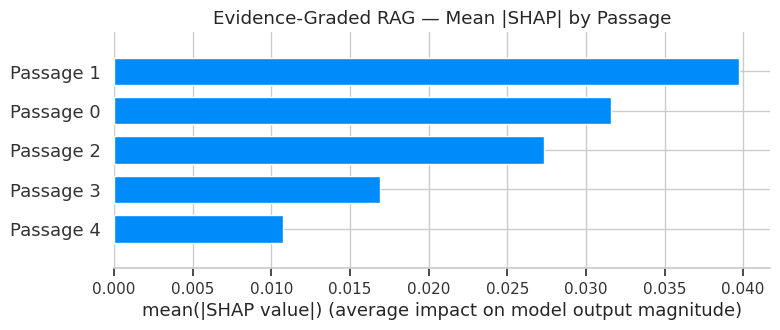

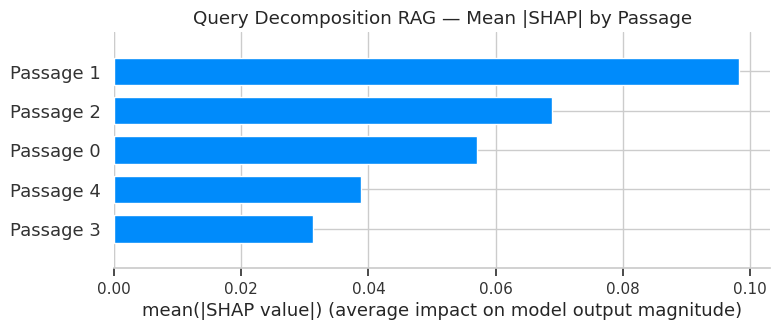

In [18]:
for arch_name in ARCHITECTURES:
    output_file = RESULTS_DIR / f"shap_passage_scores_{arch_name.lower().replace(' ', '_')}.csv"
    if not output_file.exists():
        continue

    shap_df = pd.read_csv(output_file)
    shap_cols = [c for c in shap_df.columns if c.endswith("_shap")]
    shap_matrix = shap_df[shap_cols].values
    feature_names = [f"Passage {i}" for i in range(len(shap_cols))]

    plt.figure(figsize=(10, 6))
    shap.summary_plot(
        shap_matrix,
        feature_names=feature_names,
        plot_type="bar",
        show=False,
    )
    plt.title(f"{arch_name} — Mean |SHAP| by Passage")
    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR / f"shap_summary_{arch_name.lower().replace(' ', '_')}.png",
        dpi=150, bbox_inches="tight",
    )
    plt.show()

## Visualisation: SHAP Waterfall for Individual Questions

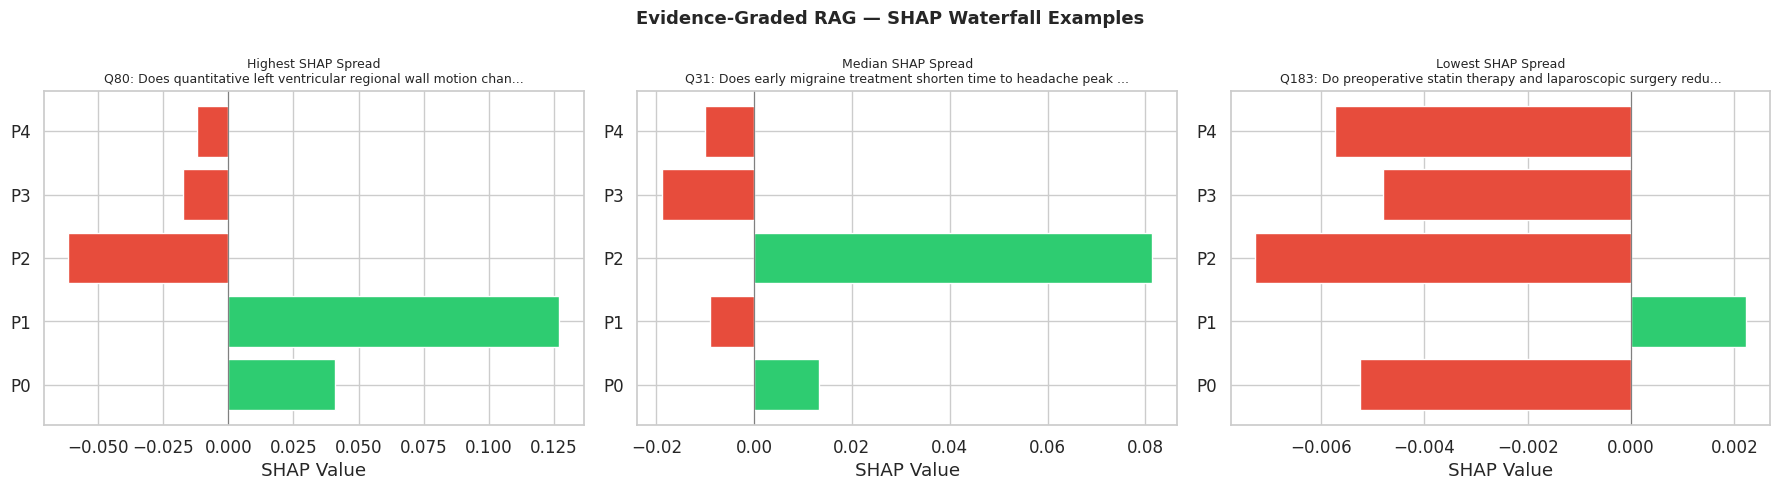

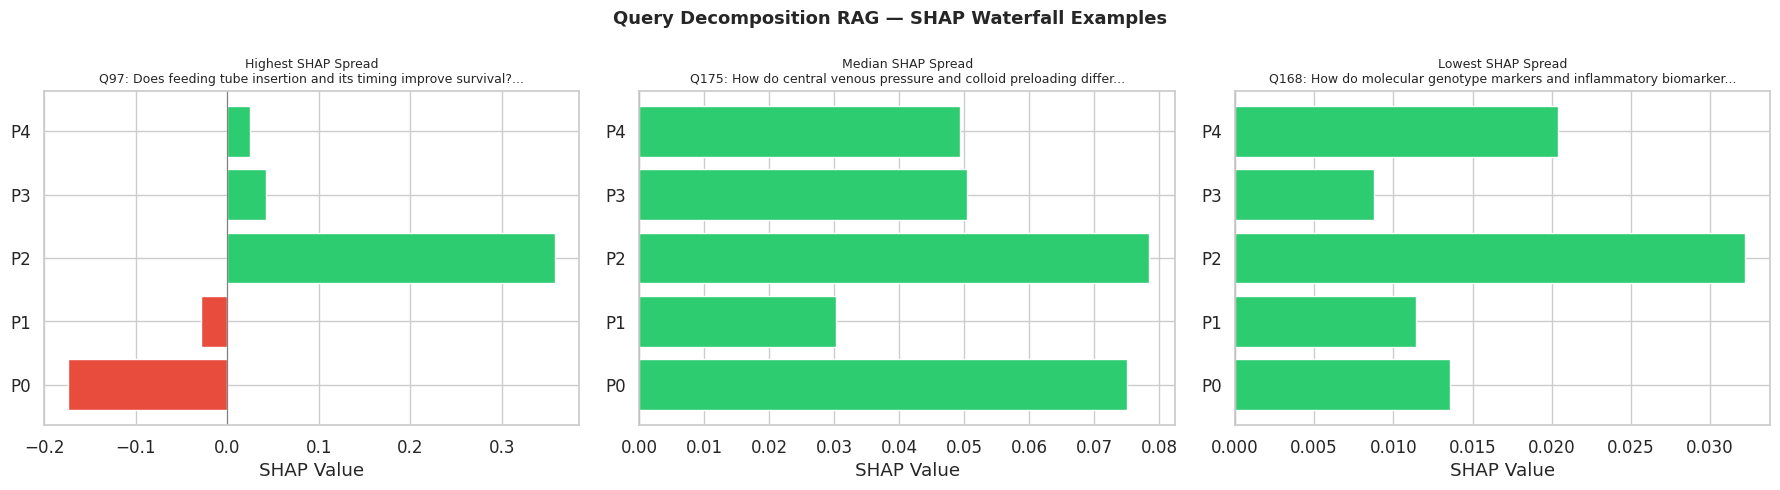

In [19]:
for arch_name in ARCHITECTURES:
    output_file = RESULTS_DIR / f"shap_passage_scores_{arch_name.lower().replace(' ', '_')}.csv"
    if not output_file.exists():
        continue

    shap_df = pd.read_csv(output_file)
    shap_cols = [c for c in shap_df.columns if c.endswith("_shap")]
    n_passages = len(shap_cols)

    # Pick 3 representative questions: highest total |SHAP|, median, lowest
    total_abs = np.abs(shap_df[shap_cols].values).sum(axis=1)
    indices = [np.argmax(total_abs), np.argsort(total_abs)[len(total_abs)//2], np.argmin(total_abs)]
    labels = ["Highest SHAP Spread", "Median SHAP Spread", "Lowest SHAP Spread"]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, idx, label in zip(axes, indices, labels):
        row = shap_df.iloc[idx]
        sv = np.array([row[c] for c in shap_cols])
        base = row["base_value"]

        colours = ["#2ecc71" if v >= 0 else "#e74c3c" for v in sv]
        ax.barh(range(n_passages), sv, color=colours, edgecolor="white")
        ax.set_yticks(range(n_passages))
        ax.set_yticklabels([f"P{i}" for i in range(n_passages)])
        ax.set_xlabel("SHAP Value")
        ax.axvline(x=0, color="gray", linewidth=0.8)
        q_text = row["question"][:60] + "..."
        ax.set_title(f"{label}\nQ{int(row['question_idx'])}: {q_text}", fontsize=9)

    plt.suptitle(f"{arch_name} — SHAP Waterfall Examples", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR / f"shap_waterfall_{arch_name.lower().replace(' ', '_')}.png",
        dpi=150, bbox_inches="tight",
    )
    plt.show()

## Visualisation: SHAP Heatmap Across Questions

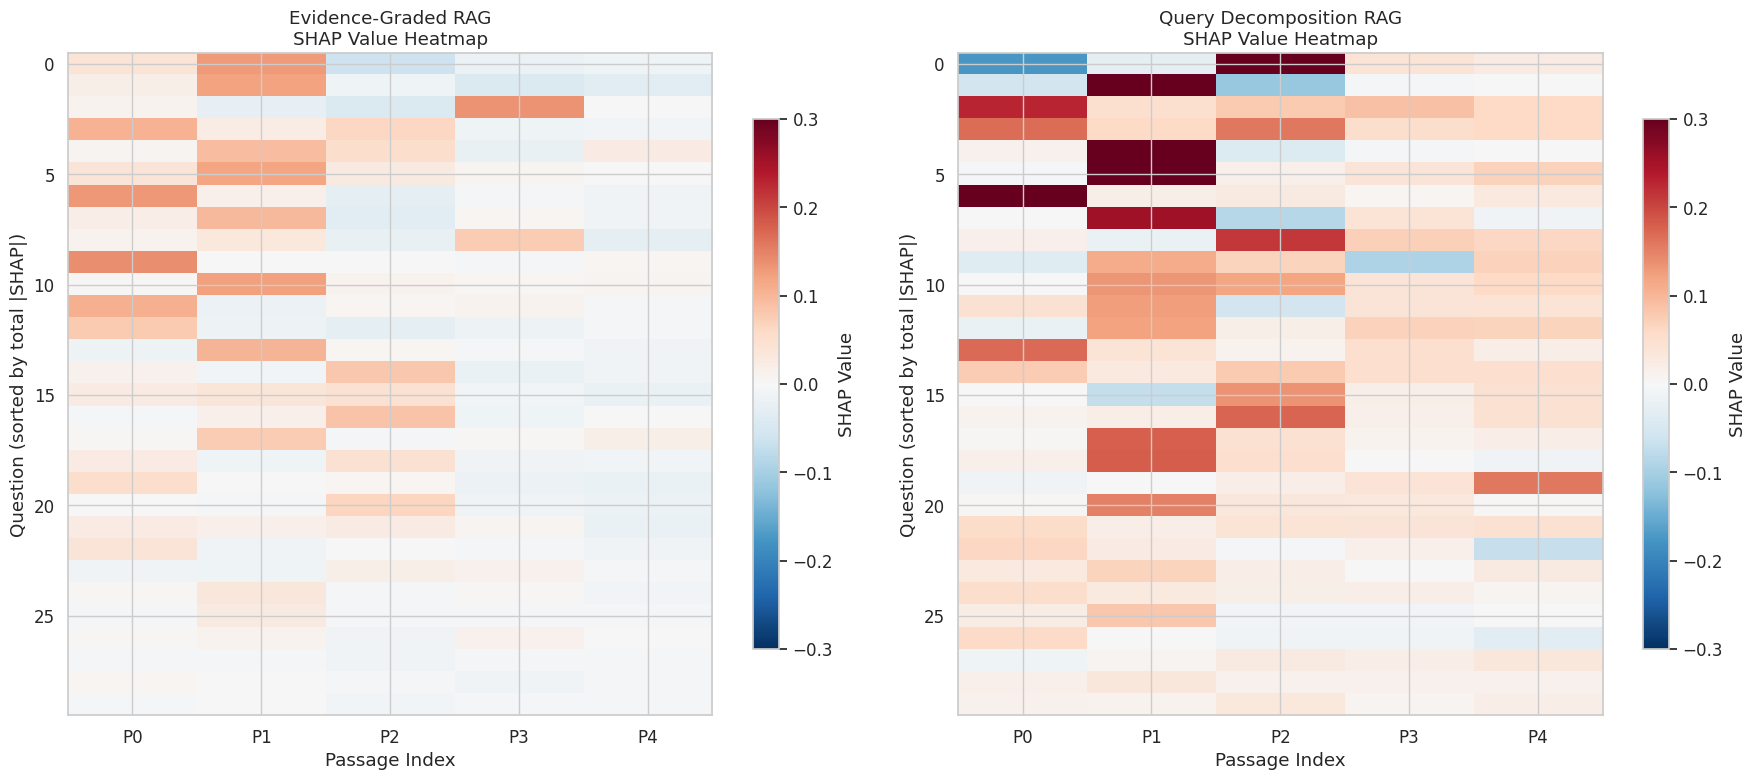

Saved: shap_heatmap.png


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax_idx, arch_name in enumerate(ARCHITECTURES):
    output_file = RESULTS_DIR / f"shap_passage_scores_{arch_name.lower().replace(' ', '_')}.csv"
    if not output_file.exists():
        continue

    shap_df = pd.read_csv(output_file)
    shap_cols = [c for c in shap_df.columns if c.endswith("_shap")]
    shap_matrix = shap_df[shap_cols].values

    sort_idx = np.argsort(np.abs(shap_matrix).sum(axis=1))[::-1]
    display_matrix = shap_matrix[sort_idx[:30]]  # all sampled questions

    ax = axes[ax_idx]
    im = ax.imshow(display_matrix, aspect="auto", cmap="RdBu_r", vmin=-0.3, vmax=0.3)
    ax.set_xlabel("Passage Index")
    ax.set_ylabel("Question (sorted by total |SHAP|)")
    ax.set_title(f"{arch_name}\nSHAP Value Heatmap")
    ax.set_xticks(range(len(shap_cols)))
    ax.set_xticklabels([f"P{i}" for i in range(len(shap_cols))])
    plt.colorbar(im, ax=ax, label="SHAP Value", shrink=0.8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: shap_heatmap.png")

## Correlation: SHAP Values vs Answer Quality Metrics

Correlates passage-level SHAP values with two answer quality dimensions:
- **Faithfulness:** Is the answer grounded in the retrieved passages? (Often saturated at 1.0 — if all sampled questions score perfectly, correlation is undefined due to zero variance.)
- **Answer Correctness:** Does the generated answer match the golden answer? (Has natural spread across questions, making it more informative for correlation analysis.)

In [21]:
for arch_name, df in datasets.items():
    output_file = RESULTS_DIR / f"shap_passage_scores_{arch_name.lower().replace(' ', '_')}.csv"
    if not output_file.exists():
        continue

    shap_df = pd.read_csv(output_file)
    shap_cols = [c for c in shap_df.columns if c.endswith("_shap")]
    shap_df["max_abs_shap"] = shap_df[shap_cols].abs().max(axis=1)
    shap_df["shap_concentration"] = shap_df[shap_cols].abs().max(axis=1) / (shap_df[shap_cols].abs().sum(axis=1) + 1e-8)

    print(f"\n{'='*50}")
    print(f"{arch_name}")
    print(f"{'='*50}")

    # --- Faithfulness ---
    faith_cols = [c for c in df.columns if "faithfulness" in c.lower() or "Faithfulness" in c]
    if faith_cols:
        merged = shap_df.merge(df[["question_idx"] + faith_cols], on="question_idx", how="inner")
        faith_col = faith_cols[0]
        if merged[faith_col].nunique() <= 1:
            print(f"\n  Faithfulness: all {len(merged)} sampled questions score {merged[faith_col].iloc[0]:.1f}")
            print(f"    → Zero variance — Pearson correlation is undefined (NaN)")
        else:
            print(f"\n  Faithfulness (unique values: {merged[faith_col].nunique()}):")
            print(f"    Pearson(max |SHAP|, faithfulness)        = {merged['max_abs_shap'].corr(merged[faith_col]):.3f}")
            print(f"    Pearson(SHAP concentration, faithfulness) = {merged['shap_concentration'].corr(merged[faith_col]):.3f}")

    # --- Answer Correctness ---
    corr_cols = [c for c in df.columns if "correctness" in c.lower() or "Correctness" in c]
    if corr_cols:
        merged = shap_df.merge(df[["question_idx"] + corr_cols], on="question_idx", how="inner")
        corr_col = corr_cols[0]
        if merged[corr_col].nunique() <= 1:
            print(f"\n  Answer Correctness: all {len(merged)} sampled questions score {merged[corr_col].iloc[0]:.1f}")
            print(f"    → Zero variance — Pearson correlation is undefined (NaN)")
        else:
            print(f"\n  Answer Correctness (unique values: {merged[corr_col].nunique()}):")
            print(f"    Pearson(max |SHAP|, correctness)        = {merged['max_abs_shap'].corr(merged[corr_col]):.3f}")
            print(f"    Pearson(SHAP concentration, correctness) = {merged['shap_concentration'].corr(merged[corr_col]):.3f}")


Evidence-Graded RAG

  Faithfulness (unique values: 3):
    Pearson(max |SHAP|, faithfulness)        = 0.074
    Pearson(SHAP concentration, faithfulness) = 0.195

  Answer Correctness (unique values: 7):
    Pearson(max |SHAP|, correctness)        = 0.269
    Pearson(SHAP concentration, correctness) = 0.257

Query Decomposition RAG

  Faithfulness: all 30 sampled questions score 1.0
    → Zero variance — Pearson correlation is undefined (NaN)

  Answer Correctness (unique values: 9):
    Pearson(max |SHAP|, correctness)        = 0.060
    Pearson(SHAP concentration, correctness) = -0.056


## Summary Table

In [22]:
summary_rows = []
for arch_name in ARCHITECTURES:
    output_file = RESULTS_DIR / f"shap_passage_scores_{arch_name.lower().replace(' ', '_')}.csv"
    if not output_file.exists():
        continue

    shap_df = pd.read_csv(output_file)
    shap_cols = [c for c in shap_df.columns if c.endswith("_shap")]
    shap_matrix = shap_df[shap_cols].values

    summary_rows.append({
        "Architecture": arch_name,
        "N Questions": len(shap_df),
        "N Passages": len(shap_cols),
        "Mean Base Value": f"{shap_df['base_value'].mean():.3f}",
        "Mean Sum SHAP": f"{shap_matrix.sum(axis=1).mean():.3f}",
        "Mean Max |SHAP|": f"{np.abs(shap_matrix).max(axis=1).mean():.4f}",
        "Mean SHAP Concentration": f"{(np.abs(shap_matrix).max(axis=1) / (np.abs(shap_matrix).sum(axis=1) + 1e-8)).mean():.3f}",
    })

pd.DataFrame(summary_rows)

,Architecture,N Questions,N Passages,Mean Base Value,Mean Sum SHAP,Mean Max |SHAP|,Mean SHAP Concentration
0,Evidence-Graded RAG,30,5,0.115,0.063,0.0729,0.545
1,Query Decomposition RAG,30,5,0.072,0.228,0.1616,0.525
